In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot  as plt
import seaborn as sns
sns.set(style="whitegrid")

In [2]:
df = pd.read_csv('train.csv', index_col='id')
df['date_sold'] = pd.to_datetime(df['date_sold'])
df['year_sold'] = df['date_sold'].dt.year

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5016 entries, 4863 to 6891
Data columns (total 44 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   price                                      5016 non-null   float64       
 1   date_sold                                  5016 non-null   datetime64[ns]
 2   suburb                                     5016 non-null   object        
 3   num_bath                                   5016 non-null   int64         
 4   num_bed                                    5016 non-null   int64         
 5   num_parking                                5016 non-null   int64         
 6   property_size                              5016 non-null   int64         
 7   type                                       5016 non-null   object        
 8   suburb_population                          5016 non-null   float64       
 9   suburb_median_income 

### Mean price by region ###

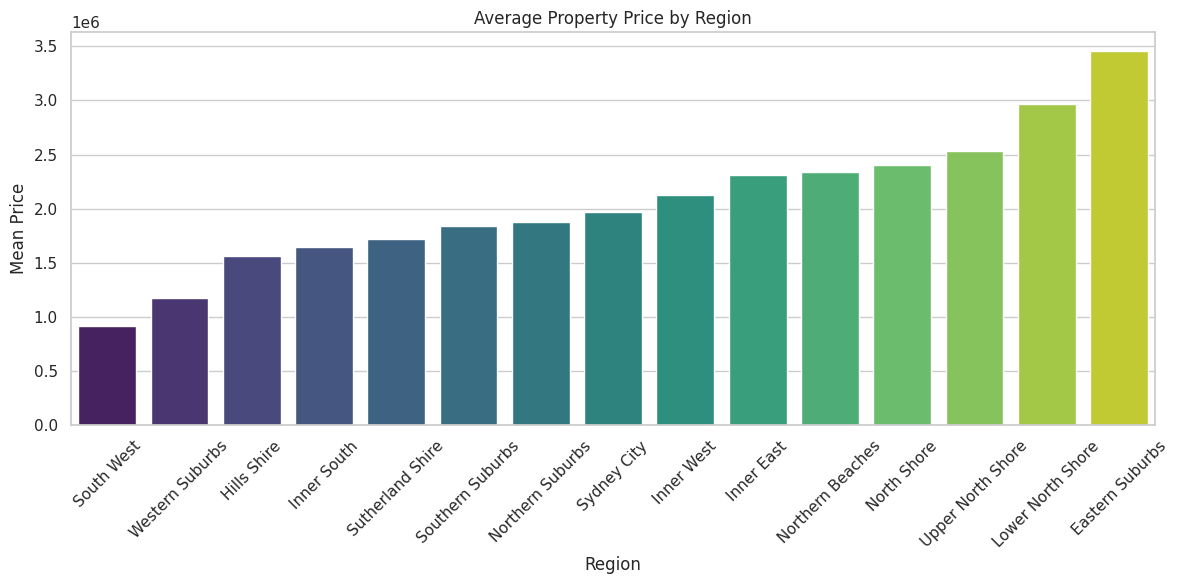

In [4]:
region_means = df.groupby('region')['price'].mean().sort_values().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=region_means, x='region', y='price', hue='region', palette='viridis', legend=False)
plt.xticks(rotation=45)
plt.title("Average Property Price by Region")
plt.ylabel("Mean Price")
plt.xlabel("Region")
plt.tight_layout()
plt.show()


### Mean price by Type ###

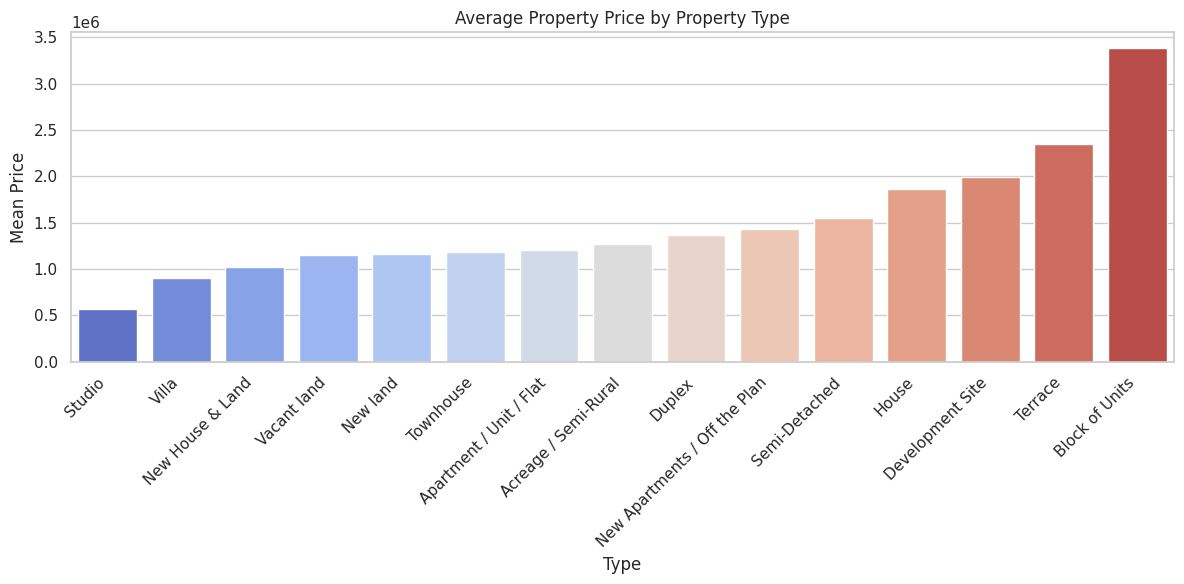

In [5]:
type_means = df.groupby('type')['price'].mean().sort_values().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=type_means, x='type', y='price', hue='type', palette='coolwarm', legend=False)
plt.xticks(rotation=45, ha='right') 
plt.title("Average Property Price by Property Type")
plt.ylabel("Mean Price")
plt.xlabel("Type")
plt.tight_layout()
plt.show()


### Year Sold ###

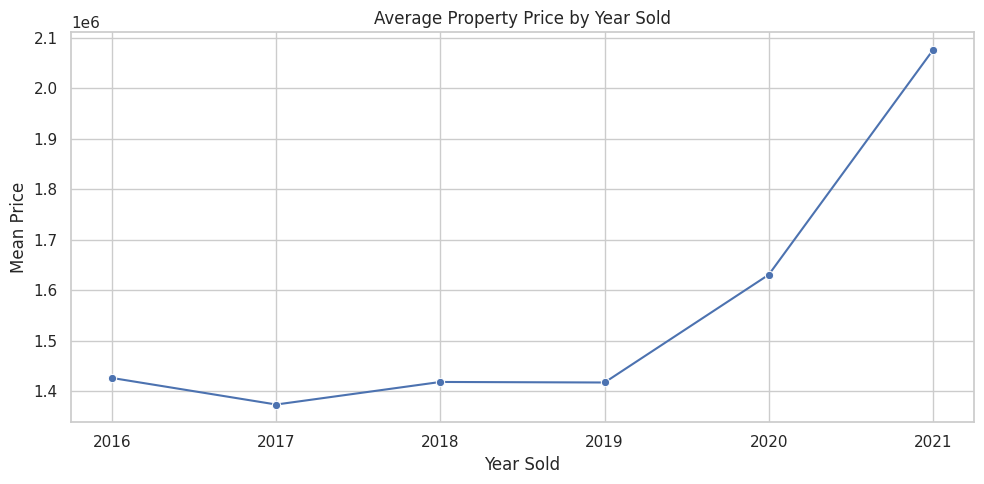

In [6]:
year_means = df.groupby('year_sold')['price'].mean().sort_index().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=year_means.head(6), x='year_sold', y='price', marker='o')
plt.title("Average Property Price by Year Sold")
plt.ylabel("Mean Price")
plt.xlabel("Year Sold")
plt.grid(True)
plt.tight_layout()
plt.show()

### Number of Rooms ###

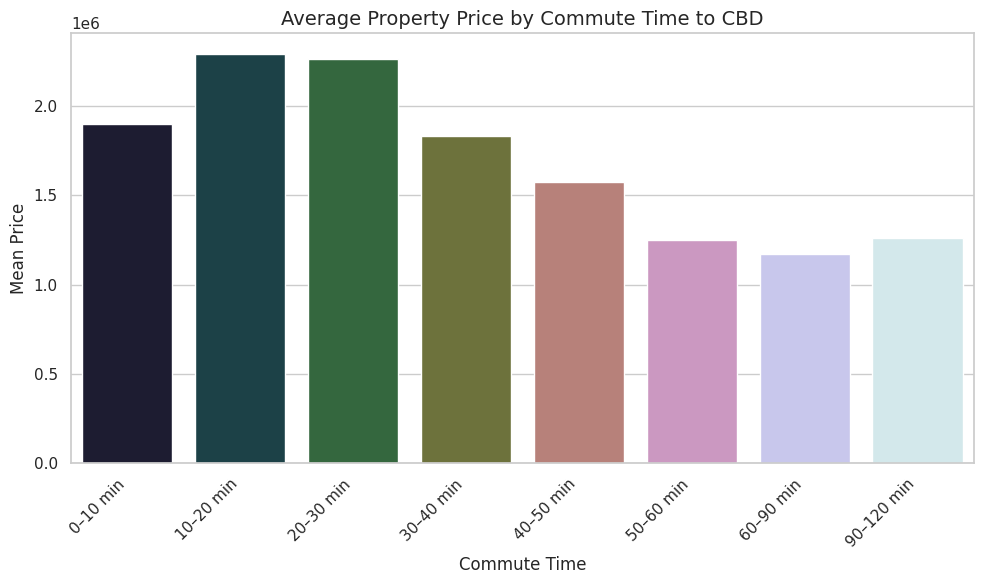

In [19]:
# Ensure commute_time is calculated
df['time_to_cbd_public_transport_town_hall_st'] = df['time_to_cbd_public_transport_town_hall_st'].fillna(df['time_to_cbd_public_transport_town_hall_st'].mean())
df['time_to_cbd_driving_town_hall_st'] = df['time_to_cbd_driving_town_hall_st'].fillna(df['time_to_cbd_driving_town_hall_st'].mean())
df['commute_time'] = (df['time_to_cbd_public_transport_town_hall_st'] + df['time_to_cbd_driving_town_hall_st']) / 2

df['commute_bin'] = pd.cut(df['commute_time'], bins=[0, 10, 20, 30, 40, 50, 60, 90, 120])

# Calculate mean price per bin
# commute_means = df.groupby('commute_bin')['price'].mean().reset_index()
commute_means = df.groupby('commute_bin', observed=True)['price'].mean().reset_index()

# Format bin labels for readability
commute_means['bin_label'] = commute_means['commute_bin'].apply(
    lambda x: f"{int(x.left)}–{int(x.right)} min"
)

# Plot with cleaner labels
plt.figure(figsize=(10, 6))
sns.barplot(data=commute_means, x='bin_label', hue='bin_label', y='price', palette='cubehelix', legend=False)
plt.title("Average Property Price by Commute Time to CBD", fontsize=14)
plt.xlabel("Commute Time", fontsize=12)
plt.ylabel("Mean Price", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



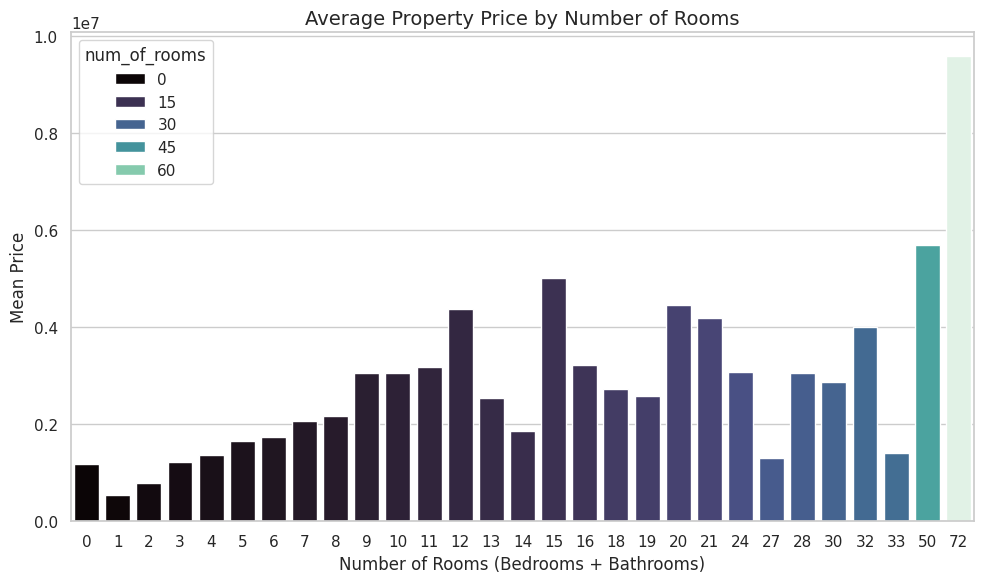

In [7]:
# Create num_of_rooms if not already
df['num_of_rooms'] = df['num_bed'] + df['num_bath']

# Group by and compute mean price
room_means = df.groupby('num_of_rooms')['price'].mean().reset_index()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=room_means, x='num_of_rooms',hue='num_of_rooms', y='price', palette='mako')

plt.title("Average Property Price by Number of Rooms", fontsize=14)
plt.xlabel("Number of Rooms (Bedrooms + Bathrooms)", fontsize=12)
plt.ylabel("Mean Price", fontsize=12)
plt.tight_layout()
plt.show()


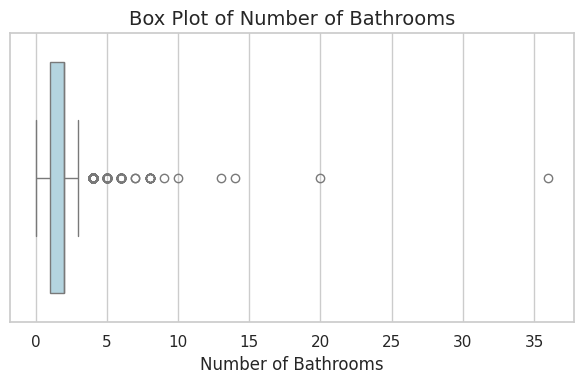

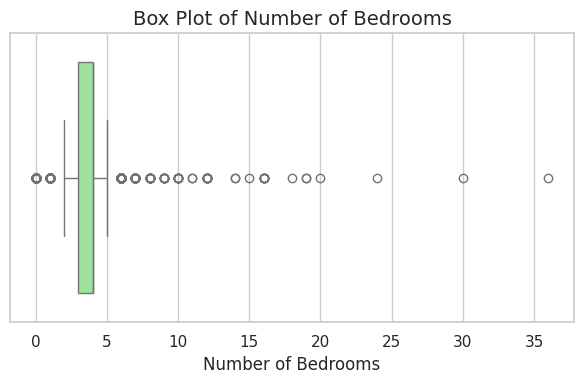

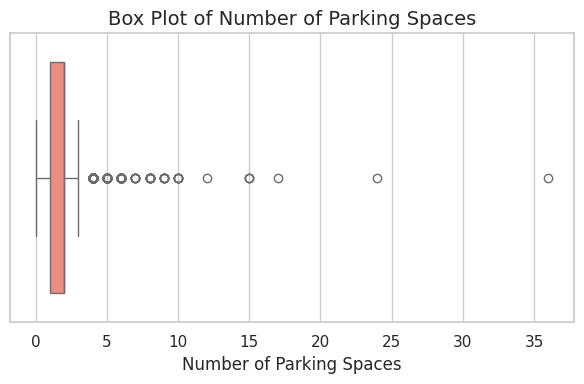

In [8]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['num_bath'], color='lightblue')
plt.title("Box Plot of Number of Bathrooms", fontsize=14)
plt.xlabel("Number of Bathrooms")
plt.tight_layout()
plt.show()

# Box Plot for num_bed
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['num_bed'], color='lightgreen')
plt.title("Box Plot of Number of Bedrooms", fontsize=14)
plt.xlabel("Number of Bedrooms")
plt.tight_layout()
plt.show()

# Box Plot for num_parking
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['num_parking'], color='salmon')
plt.title("Box Plot of Number of Parking Spaces", fontsize=14)
plt.xlabel("Number of Parking Spaces")
plt.tight_layout()
plt.show()

In [20]:
df.type.value_counts()

type
House                            4110
Apartment / Unit / Flat           441
Townhouse                         121
Semi-Detached                      87
Vacant land                        73
Villa                              58
Terrace                            44
Duplex                             36
Block of Units                     23
New House & Land                    9
Studio                              5
New Apartments / Off the Plan       5
Development Site                    2
Acreage / Semi-Rural                1
New land                            1
Name: count, dtype: int64

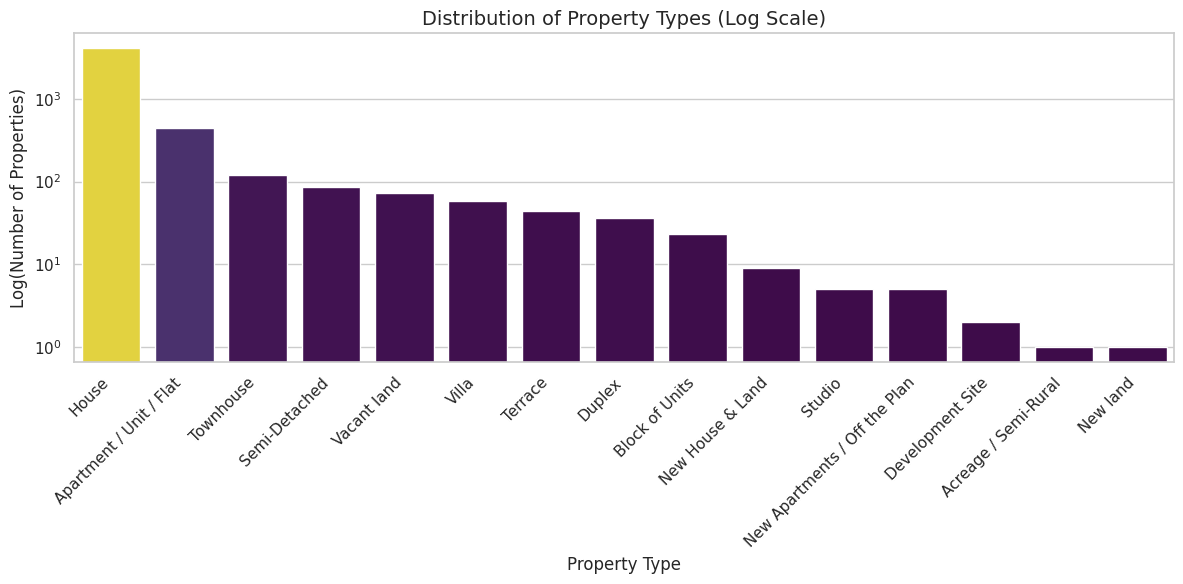

In [28]:
type_counts = df['type'].value_counts()

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=type_counts.index, y=type_counts.values,hue=type_counts.values,palette="viridis",legend=False)

plt.yscale('log')  # Log scale for better visualization of smaller counts
plt.title("Distribution of Property Types (Log Scale)", fontsize=14)
plt.xlabel("Property Type", fontsize=12)
plt.ylabel("Log(Number of Properties)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()